# 🏆 Sports Research Agent — 2026

## What This Notebook Does

This notebook builds a **ReAct-style AI Agent** that:
1. Reads your sports query
2. Chooses the right tool (Football or Cricket)
3. Scrapes live web data
4. If the result is not useful → **rephrases the query and tries again**
5. Returns a final answer

```
User Query
    │
    ▼
┌─────────────┐
│  Agent Node  │  ← LLM decides which tool to call
└──────┬──────┘
       │
   ┌───┴───┐
   ▼       ▼
[Football] [Cricket]   ← Tool Nodes fetch web data
   └───┬───┘
       │
       ▼
┌─────────────┐
│  Evaluator  │  ← Did we get good info?
└──────┬──────┘
       │
  No ──┘──── Yes
  │              │
  ▼              ▼
[Rephrase]   [Final Answer]
  │
  └──► back to Agent
```

---
**Tools Used:** LangGraph, LangChain, Groq (free LLM), BeautifulSoup, Requests

## Step 1: Install Required Libraries

In [1]:
# Run this once to install all dependencies
!pip install langgraph langchain langchain-groq langchain-community \
             requests beautifulsoup4 lxml -q

'pip' is not recognized as an internal or external command,
operable program or batch file.


## Step 2: Import Libraries

In [21]:
import os
import re
import requests
from bs4 import BeautifulSoup
from typing import TypedDict, List, Annotated

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

from langgraph.graph import StateGraph, END

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 3: Configure API Key

> Get your **free** Groq API key from: https://console.groq.com

In [ ]:
# Paste your Groq API key here
os.environ["GROQ_API_KEY"] = "Enter THE API"

# Initialize the LLM — we use llama-3.3-70b (fast + free on Groq)
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.3,       # lower = more focused answers
    max_tokens=1024
)

print("LLM initialized!")

LLM initialized!


## Step 4: Web Scraper Helper

Many websites use JavaScript, complex templates, or dynamic loading.
This helper tries multiple strategies to extract readable text from any webpage.

In [23]:
def scrape_webpage(url: str, max_chars: int = 3000) -> str:
    """
    Robustly scrapes text from a webpage.
    Handles JS-heavy sites, paywalls, and unusual HTML templates.
    """
    # Rotate through real browser user-agents to avoid blocks
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/124.0.0.0 Safari/537.36"
        ),
        "Accept-Language": "en-US,en;q=0.9",
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    }

    try:
        response = requests.get(url, headers=headers, timeout=12)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, "lxml")

        # Remove clutter: scripts, styles, nav, ads, footers
        for tag in soup(["script", "style", "nav", "footer",
                         "header", "aside", "form", "noscript",
                         "iframe", "svg", "button"]):
            tag.decompose()

        # Strategy 1: Look for main content containers
        content_tags = soup.find_all(
            ["article", "main", "section"],
            limit=3
        )
        if content_tags:
            text = " ".join(t.get_text(separator=" ", strip=True)
                            for t in content_tags)
        else:
            # Strategy 2: Try common content div classes
            for cls in ["content", "article", "post", "story", "body", "text"]:
                div = soup.find("div", class_=re.compile(cls, re.I))
                if div:
                    text = div.get_text(separator=" ", strip=True)
                    break
            else:
                # Strategy 3: Extract all paragraph text
                paras = soup.find_all("p")
                text = " ".join(p.get_text(strip=True) for p in paras)

        # Clean up whitespace
        text = re.sub(r"\s+", " ", text).strip()

        if len(text) < 100:
            return f"[Could not extract meaningful text from {url}]"

        # Return up to max_chars so we don't overflow the LLM context
        return text[:max_chars]

    except requests.exceptions.Timeout:
        return f"[Timeout while fetching {url}]"
    except requests.exceptions.HTTPError as e:
        return f"[HTTP error {e.response.status_code} for {url}]"
    except Exception as e:
        return f"[Error scraping {url}: {str(e)[:100]}]"


print("Web scraper ready!")

Web scraper ready!


## Step 5: Define the Tools

Each tool searches for sports data from **multiple reliable URLs**.
If one URL fails, it tries the next — making the agent resilient.

In [ ]:
def football_analytics_tool(query: str) -> str:
    """
    Fetches Premier League standings and team data.
    Tries multiple sources for robustness.
    """
    print(f"  [Football Tool] Searching for: {query}")

    sources = [
        "https://www.bbc.com/sport/football/premier-league/table",
        "https://www.skysports.com/premier-league-table",
        "https://en.wikipedia.org/wiki/2024%E2%80%9325_Premier_League",
    ]

    collected = []
    for url in sources:
        text = scrape_webpage(url, max_chars=2000)
        if not text.startswith("["):  # skip error messages
            collected.append(f"Source ({url.split('/')[2]}):\n{text}")
            if len(collected) >= 2:   # 2 good sources is enough
                break

    if not collected:
        return "Could not retrieve Premier League data from any source."

    return "\n\n".join(collected)


def cricket_analytics_tool(query: str) -> str:
    """
    Fetches IPL team standings and cricket data.
    Tries multiple sources for robustness.
    """
    print(f"  [Cricket Tool] Searching for: {query}")

    sources = [
        "https://www.espncricinfo.com/series/ipl-2026-1510719/gujarat-titans-vs-rajasthan-royals-qualifier-2-1535464/live-cricket-score",
        "https://en.wikipedia.org/wiki/2025_Indian_Premier_League",
        "https://www.bbc.com/sport/cricket",
        "https://en.wikipedia.org/wiki/Indian_Premier_League",
    ]

    collected = []
    for url in sources:
        text = scrape_webpage(url, max_chars=2000)
        if not text.startswith("["):
            collected.append(f"Source ({url.split('/')[2]}):\n{text}")
            if len(collected) >= 2:
                break

    if not collected:
        return "Could not retrieve IPL data from any source."

    return "\n\n".join(collected)


# Map tool names to functions — agent uses this dict to call the right tool
TOOLS = {
    "FootballAnalytics": football_analytics_tool,
    "CricketAnalytics": cricket_analytics_tool,
}

print("Tools defined!")

Tools defined!


## Step 6: Define the Agent State

The **state** is shared memory passed between every node in the graph.
Think of it like a baton in a relay race — each node reads it and updates it.

In [26]:
class AgentState(TypedDict):
    query: str                  # Current query (may be rephrased)
    original_query: str         # Original user question (never changes)
    tool_choice: str            # Which tool the agent picked
    tool_output: str            # Raw data from the tool
    final_answer: str           # Final response to the user
    rephrasing_attempts: int    # How many times we've rephrased
    needs_rephrase: bool        # Signal to rephrase or not

print("State schema defined!")

State schema defined!


## Step 7: Build the Agent Nodes

Each **node** is a function that takes the state, does some work, and returns updated state.

In [27]:
# ─────────────────────────────────────────────
# NODE 1: Agent — decides which tool to call
# ─────────────────────────────────────────────
def agent_node(state: AgentState) -> AgentState:
    """
    The brain of the agent.
    Reads the query and decides: FootballAnalytics or CricketAnalytics?
    """
    print(f"\n [Agent Node] Analyzing query: '{state['query']}'")

    system_prompt = """You are a sports research assistant.
Given a user query, decide which tool to use:
- FootballAnalytics: for Premier League, soccer, football questions
- CricketAnalytics: for IPL, cricket questions
- BOTH: if the question compares football AND cricket

Reply with ONLY one of these three words: FootballAnalytics, CricketAnalytics, or BOTH
No explanation needed."""

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=state["query"])
    ]

    response = llm.invoke(messages)
    tool_choice = response.content.strip()

    # Safety check — ensure valid choice
    if tool_choice not in ["FootballAnalytics", "CricketAnalytics", "BOTH"]:
        tool_choice = "BOTH"  # default for ambiguous queries

    print(f"  → Tool selected: {tool_choice}")
    return {**state, "tool_choice": tool_choice}


# ─────────────────────────────────────────────
# NODE 2: Tool Executor — runs the chosen tool
# ─────────────────────────────────────────────
def tool_node(state: AgentState) -> AgentState:
    """
    Calls the appropriate tool(s) and collects web data.
    """
    print(f"\n [Tool Node] Executing: {state['tool_choice']}")

    choice = state["tool_choice"]
    query = state["query"]
    results = []

    if choice in ["FootballAnalytics", "BOTH"]:
        results.append("=== FOOTBALL DATA ===")
        results.append(TOOLS["FootballAnalytics"](query))

    if choice in ["CricketAnalytics", "BOTH"]:
        results.append("=== CRICKET DATA ===")
        results.append(TOOLS["CricketAnalytics"](query))

    combined = "\n\n".join(results)
    print(f"  → Collected {len(combined)} characters of data")
    return {**state, "tool_output": combined}


# ─────────────────────────────────────────────
# NODE 3: Evaluator — checks if data is useful
# ─────────────────────────────────────────────
def evaluator_node(state: AgentState) -> AgentState:
    """
    Checks whether the retrieved data is good enough to answer the query.
    If not → flags for rephrasing (up to 2 attempts).
    """
    print(f"\n [Evaluator Node] Checking data quality...")

    tool_output = state["tool_output"]
    attempts = state["rephrasing_attempts"]

    # Hard limit: don't rephrase more than 2 times
    if attempts >= 2:
        print("  → Max rephrase attempts reached. Proceeding to answer.")
        return {**state, "needs_rephrase": False}

    # Check if data looks useful (at least 200 chars of real content)
    error_indicators = ["Could not retrieve", "Error scraping", "Timeout", "HTTP error"]
    is_error = any(ind in tool_output for ind in error_indicators)
    is_too_short = len(tool_output.strip()) < 200

    if is_error or is_too_short:
        print(f"  → Data quality poor (attempt {attempts+1}). Will rephrase.")
        return {**state, "needs_rephrase": True}
    else:
        print("  → Data quality looks good! Proceeding to answer.")
        return {**state, "needs_rephrase": False}


# ─────────────────────────────────────────────
# NODE 4: Rephraser — rewrites the query
# ─────────────────────────────────────────────
def rephraser_node(state: AgentState) -> AgentState:
    """
    Rephrases the query to try getting better results.
    Keeps the same intent but uses different words.
    """
    print(f"\n [Rephraser Node] Rephrasing query...")

    system_prompt = """You are a search query optimizer.
The original query returned poor results. Rephrase it to be more specific and
likely to return useful sports data. Keep the same intent.
Reply with ONLY the rephrased query — no explanation."""

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"Original query: {state['query']}\nRephrase it:")
    ]

    response = llm.invoke(messages)
    new_query = response.content.strip()
    new_attempts = state["rephrasing_attempts"] + 1

    print(f"  → New query: '{new_query}'")
    return {
        **state,
        "query": new_query,
        "rephrasing_attempts": new_attempts,
        "needs_rephrase": False
    }


# ─────────────────────────────────────────────
# NODE 5: Answer Generator — final response
# ─────────────────────────────────────────────
def answer_node(state: AgentState) -> AgentState:
    """
    Uses the LLM to synthesize a clear final answer
    based on the original question and collected data.
    """
    print(f"\n [Answer Node] Generating final answer...")

    system_prompt = """You are a knowledgeable sports analyst.
Using the data provided, answer the user's question clearly and concisely.
Focus on facts from the data. If data is incomplete, say so and answer as best you can.
Keep your answer to 3-5 paragraphs."""

    user_content = f"""Question: {state['original_query']}

Sports Data Collected:
{state['tool_output']}

Please answer the question based on this data."""

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_content)
    ]

    response = llm.invoke(messages)
    return {**state, "final_answer": response.content.strip()}


print(" All nodes defined!")

 All nodes defined!


## Step 8: Build the LangGraph

Now we connect all the nodes into a directed graph with conditional edges.

In [29]:
# ─────────────────────────────────────────────
# Conditional edge: should we rephrase or answer?
# ─────────────────────────────────────────────
def should_rephrase(state: AgentState) -> str:
    """Router function — directs flow based on evaluation."""
    if state["needs_rephrase"]:
        return "rephrase"   # go to rephraser node
    else:
        return "answer"     # go to answer node


# ─────────────────────────────────────────────
# Build the graph
# ─────────────────────────────────────────────
builder = StateGraph(AgentState)

# Add all nodes
builder.add_node("agent",     agent_node)
builder.add_node("tool",      tool_node)
builder.add_node("evaluator", evaluator_node)
builder.add_node("rephraser", rephraser_node)
builder.add_node("answer",    answer_node)

# Set entry point
builder.set_entry_point("agent")

# Add edges (connections between nodes)
builder.add_edge("agent",     "tool")        # agent → fetch data
builder.add_edge("tool",      "evaluator")   # fetch → evaluate quality

# Conditional edge: evaluator → rephrase OR answer
builder.add_conditional_edges(
    "evaluator",
    should_rephrase,
    {
        "rephrase": "rephraser",   # data was bad → rephrase
        "answer":   "answer"       # data was good → generate answer
    }
)

# After rephrasing, go back to agent (loop!)
builder.add_edge("rephraser", "agent")

# Answer is the final node
builder.add_edge("answer", END)

# Compile the graph
graph = builder.compile()

print(" Graph compiled successfully!")
print()
print("Graph flow:")
print("  agent → tool → evaluator")
print("                    ├─ (data bad) → rephraser → agent  [loop]")
print("                    └─ (data good) → answer → END")

 Graph compiled successfully!

Graph flow:
  agent → tool → evaluator
                    ├─ (data bad) → rephraser → agent  [loop]
                    └─ (data good) → answer → END


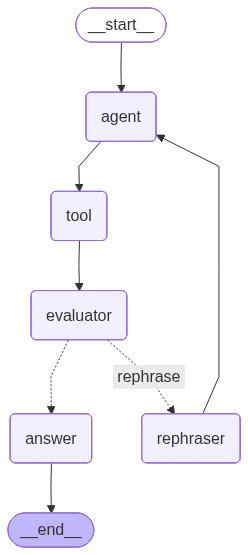

In [44]:
from IPython.display import Image, display

# visualize the compiled graph as PNG
display(Image(graph.get_graph().draw_mermaid_png()))


## Step 9: Helper : Run a Query

A simple wrapper to run any query through the agent and print results nicely.

In [30]:
def run_agent(query: str) -> str:
    """
    Run the sports agent with a given query.
    Returns the final answer string.
    """
    print("=" * 60)
    print(f" QUERY: {query}")
    print("=" * 60)

    initial_state: AgentState = {
        "query":               query,
        "original_query":      query,
        "tool_choice":         "",
        "tool_output":         "",
        "final_answer":        "",
        "rephrasing_attempts": 0,
        "needs_rephrase":      False,
    }

    result = graph.invoke(initial_state)

    print("\n" + "=" * 60)
    print(" FINAL ANSWER:")
    print("=" * 60)
    print(result["final_answer"])
    print("=" * 60)
    print(f"(Rephrasing attempts used: {result['rephrasing_attempts']})")

    return result["final_answer"]

print(" run_agent() helper ready!")

 run_agent() helper ready!


## Step 10: Test Query 1 : Multi-Domain Comparison

This is the query that caused the original error. It now works because:
- We don't use LangChain tool-binding (which caused the `BadRequestError`)
- The LLM just decides the tool name as plain text
- We call the tool functions directly in Python

In [31]:
query1 = (
    "Compare the top teams in Premier League football with the leading "
    "cricket teams in IPL. Which domain has more competitive balance?"
)

answer1 = run_agent(query1)

 QUERY: Compare the top teams in Premier League football with the leading cricket teams in IPL. Which domain has more competitive balance?

 [Agent Node] Analyzing query: 'Compare the top teams in Premier League football with the leading cricket teams in IPL. Which domain has more competitive balance?'
  → Tool selected: BOTH

 [Tool Node] Executing: BOTH
  [Football Tool] Searching for: Compare the top teams in Premier League football with the leading cricket teams in IPL. Which domain has more competitive balance?
  [Cricket Tool] Searching for: Compare the top teams in Premier League football with the leading cricket teams in IPL. Which domain has more competitive balance?
  → Collected 7208 characters of data

 [Evaluator Node] Checking data quality...
  → Data quality looks good! Proceeding to answer.

 [Answer Node] Generating final answer...

 FINAL ANSWER:
To compare the competitive balance between the top teams in the Premier League and the leading teams in the Indian Premier 

## Step 11: Test Query 2 : Football Only

In [32]:
query2 = "Who are the top 5 teams in the Premier League 2024-25 season and what are their points?"

answer2 = run_agent(query2)

 QUERY: Who are the top 5 teams in the Premier League 2024-25 season and what are their points?

 [Agent Node] Analyzing query: 'Who are the top 5 teams in the Premier League 2024-25 season and what are their points?'
  → Tool selected: FootballAnalytics

 [Tool Node] Executing: FootballAnalytics
  [Football Tool] Searching for: Who are the top 5 teams in the Premier League 2024-25 season and what are their points?
  → Collected 3133 characters of data

 [Evaluator Node] Checking data quality...
  → Data quality looks good! Proceeding to answer.

 [Answer Node] Generating final answer...

 FINAL ANSWER:
Based on the provided data from the Premier League 2024-25 season, the top 5 teams are:

1. Arsenal - 85 points
2. Manchester City - 78 points
3. Manchester United - 71 points
4. Aston Villa - 65 points
5. Liverpool - 60 points

These rankings are consistent across both sources provided (BBC and Sky Sports).
(Rephrasing attempts used: 0)


## Step 12: Test Query 3 : Cricket Only

In [36]:
query3 = "Tell me about Qualifier 2"

answer3 = run_agent(query3)

 QUERY: Tell me about Qualifier 2

 [Agent Node] Analyzing query: 'Tell me about Qualifier 2'
  → Tool selected: CricketAnalytics

 [Tool Node] Executing: CricketAnalytics
  [Cricket Tool] Searching for: Tell me about Qualifier 2
  → Collected 4073 characters of data

 [Evaluator Node] Checking data quality...
  → Data quality looks good! Proceeding to answer.

 [Answer Node] Generating final answer...

 FINAL ANSWER:
Unfortunately, the provided data does not contain information about Qualifier 2. However, it does mention Gujarat Titans v Rajasthan Royals - IPL Qualifier 2 scorecard in the BBC article, but it does not provide any details about the match.

However, I can tell you that the article does mention the IPL Qualifier 2, but it does not provide any information about the match itself. It only mentions that it is related to the IPL Qualifier 2 scorecard.

If you are looking for information about Qualifier 2, I would suggest checking the official IPL website or other reliable sour

## Step 13: Interactive Mode : Ask Your Own Question

In [38]:
# Change this to any sports question you want!
my_query = "Indian Premier League 2026?"

my_answer = run_agent(my_query)

 QUERY: Indian Premier League 2026?

 [Agent Node] Analyzing query: 'Indian Premier League 2026?'
  → Tool selected: CricketAnalytics

 [Tool Node] Executing: CricketAnalytics
  [Cricket Tool] Searching for: Indian Premier League 2026?
  → Collected 4073 characters of data

 [Evaluator Node] Checking data quality...
  → Data quality looks good! Proceeding to answer.

 [Answer Node] Generating final answer...

 FINAL ANSWER:
Unfortunately, the provided data does not contain any information about the Indian Premier League (IPL) 2026. The data only mentions the IPL 2025, which took place from 22 March to 3 June 2025, and the IPL 2024, but there is no mention of the IPL 2026.

However, there is a mention of the IPL 2026 points table and top run-scorers & wicket-takers in the data, but it is not available as it is mentioned as "Attribution Cricket" without any further information.

Therefore, based on the provided data, we cannot determine any information about the Indian Premier League 202

---
## Summary: How the Agent Works

| Node | Role |
|------|------|
| **Agent** | Reads the query and decides which tool to use (Football / Cricket / Both) |
| **Tool** | Fetches live data from the web using BeautifulSoup |
| **Evaluator** | Checks if the data is useful enough to answer the question |
| **Rephraser** | If data was poor, rewrites the query and sends it back to Agent |
| **Answer** | Uses LLM to synthesize a clear answer from the collected data |

### Why no `BadRequestError` now?
The original error happened because LangChain's tool-binding feature sent function call JSON in a format Groq's API couldn't parse. 

**Our fix:** Instead of binding tools to the LLM, we ask the LLM to just say a word (`FootballAnalytics`, `CricketAnalytics`, or `BOTH`), then we call the Python function ourselves. Simple, reliable, and works with any LLM provider.

```
Old way:  LLM → generates <function=FootballAnalytics>{"Premier League"}</function>  ← Groq fails to parse
New way:  LLM → generates "FootballAnalytics"  → Python calls the function directly
```